# Phase 4: Visualization & Dashboard
### Digital Wallet Cohort & Retention Project
**Input:** `data/cleaned/` | **Output:** `visuals/`

Five charts covering retention, acquisition quality,
funnel drop-off, friction events, and churn cost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

INPUT_DIR  = "../data/cleaned"
OUTPUT_DIR = "../visuals"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Global style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"]       = 150
plt.rcParams["savefig.dpi"]      = 150
plt.rcParams["savefig.bbox"]     = "tight"
plt.rcParams["font.family"]      = "sans-serif"
PALETTE = sns.color_palette("coolwarm", 12)

print("Libraries loaded. Output folder ready.")

Libraries loaded. Output folder ready.


## Load Cleaned Data

In [2]:
users = pd.read_csv(f"{INPUT_DIR}/cleaned_users_dim.csv")
logs  = pd.read_csv(f"{INPUT_DIR}/cleaned_user_engagement_logs.csv")
txns  = pd.read_csv(f"{INPUT_DIR}/cleaned_transactions_fact.csv")

users["signup_timestamp"]     = pd.to_datetime(users["signup_timestamp"])
logs["event_timestamp"]       = pd.to_datetime(logs["event_timestamp"])
txns["transaction_timestamp"] = pd.to_datetime(txns["transaction_timestamp"])

users["signup_cohort"] = users["signup_timestamp"].dt.to_period("M").astype(str)

print(f"users : {users.shape}")
print(f"logs  : {logs.shape}")
print(f"txns  : {txns.shape}")

users : (25000, 7)
logs  : (169340, 4)
txns  : (43023, 6)


## Chart 1: Monthly Cohort Retention Heatmap
The core retention matrix. Each row is a signup cohort (month),
each column is months since signup (0, 1, 2...).
Color intensity shows retention percentage — darker red means lower retention.
The March 2026 row should visually stand out.

In [3]:
# ── Build cohort activity table ──────────────────────────────────────────
onboarded = users[users["onboarding_completed"] == True][["user_id", "signup_cohort"]].copy()

logs_merged = logs.merge(onboarded, on="user_id", how="inner")
logs_merged["activity_month"] = pd.to_datetime(
    logs_merged["event_timestamp"]
).dt.to_period("M").astype(str)

# Cohort sizes
cohort_sizes = onboarded.groupby("signup_cohort")["user_id"].nunique().rename("cohort_size")

# Unique active users per cohort per activity month
activity = (
    logs_merged
    .groupby(["signup_cohort", "activity_month"])["user_id"]
    .nunique()
    .reset_index(name="active_users")
)

# Calculate month_number
def months_between(cohort, activity):
    c = pd.Period(cohort, "M")
    a = pd.Period(activity, "M")
    return (a.year - c.year) * 12 + (a.month - c.month)

activity["month_number"] = activity.apply(
    lambda r: months_between(r["signup_cohort"], r["activity_month"]), axis=1
)
activity = activity[activity["month_number"] >= 0]

# Merge cohort sizes
activity = activity.merge(cohort_sizes, on="signup_cohort")
activity["retention_pct"] = (
    activity["active_users"] / activity["cohort_size"] * 100
).round(2)

# Pivot into matrix
retention_matrix = activity.pivot_table(
    index   = "signup_cohort",
    columns = "month_number",
    values  = "retention_pct"
)

# Keep only month 0-8 for clean display
cols_to_show = [c for c in range(9) if c in retention_matrix.columns]
retention_matrix = retention_matrix[cols_to_show]

print(retention_matrix.head())

month_number       0      1     2     3     4     5     6     7     8
signup_cohort                                                        
2025-01        100.0  19.96  3.39  1.20  0.40  0.20  0.20  0.20   NaN
2025-02        100.0  25.10  3.39  0.40  0.20  0.40   NaN   NaN   NaN
2025-03        100.0  17.72  3.00  1.50  0.75  0.45  0.30  0.15  0.15
2025-04        100.0  18.29  2.55  1.20   NaN  0.15   NaN   NaN   NaN
2025-05        100.0  21.07  2.74  0.55  0.14  0.14  0.27   NaN   NaN


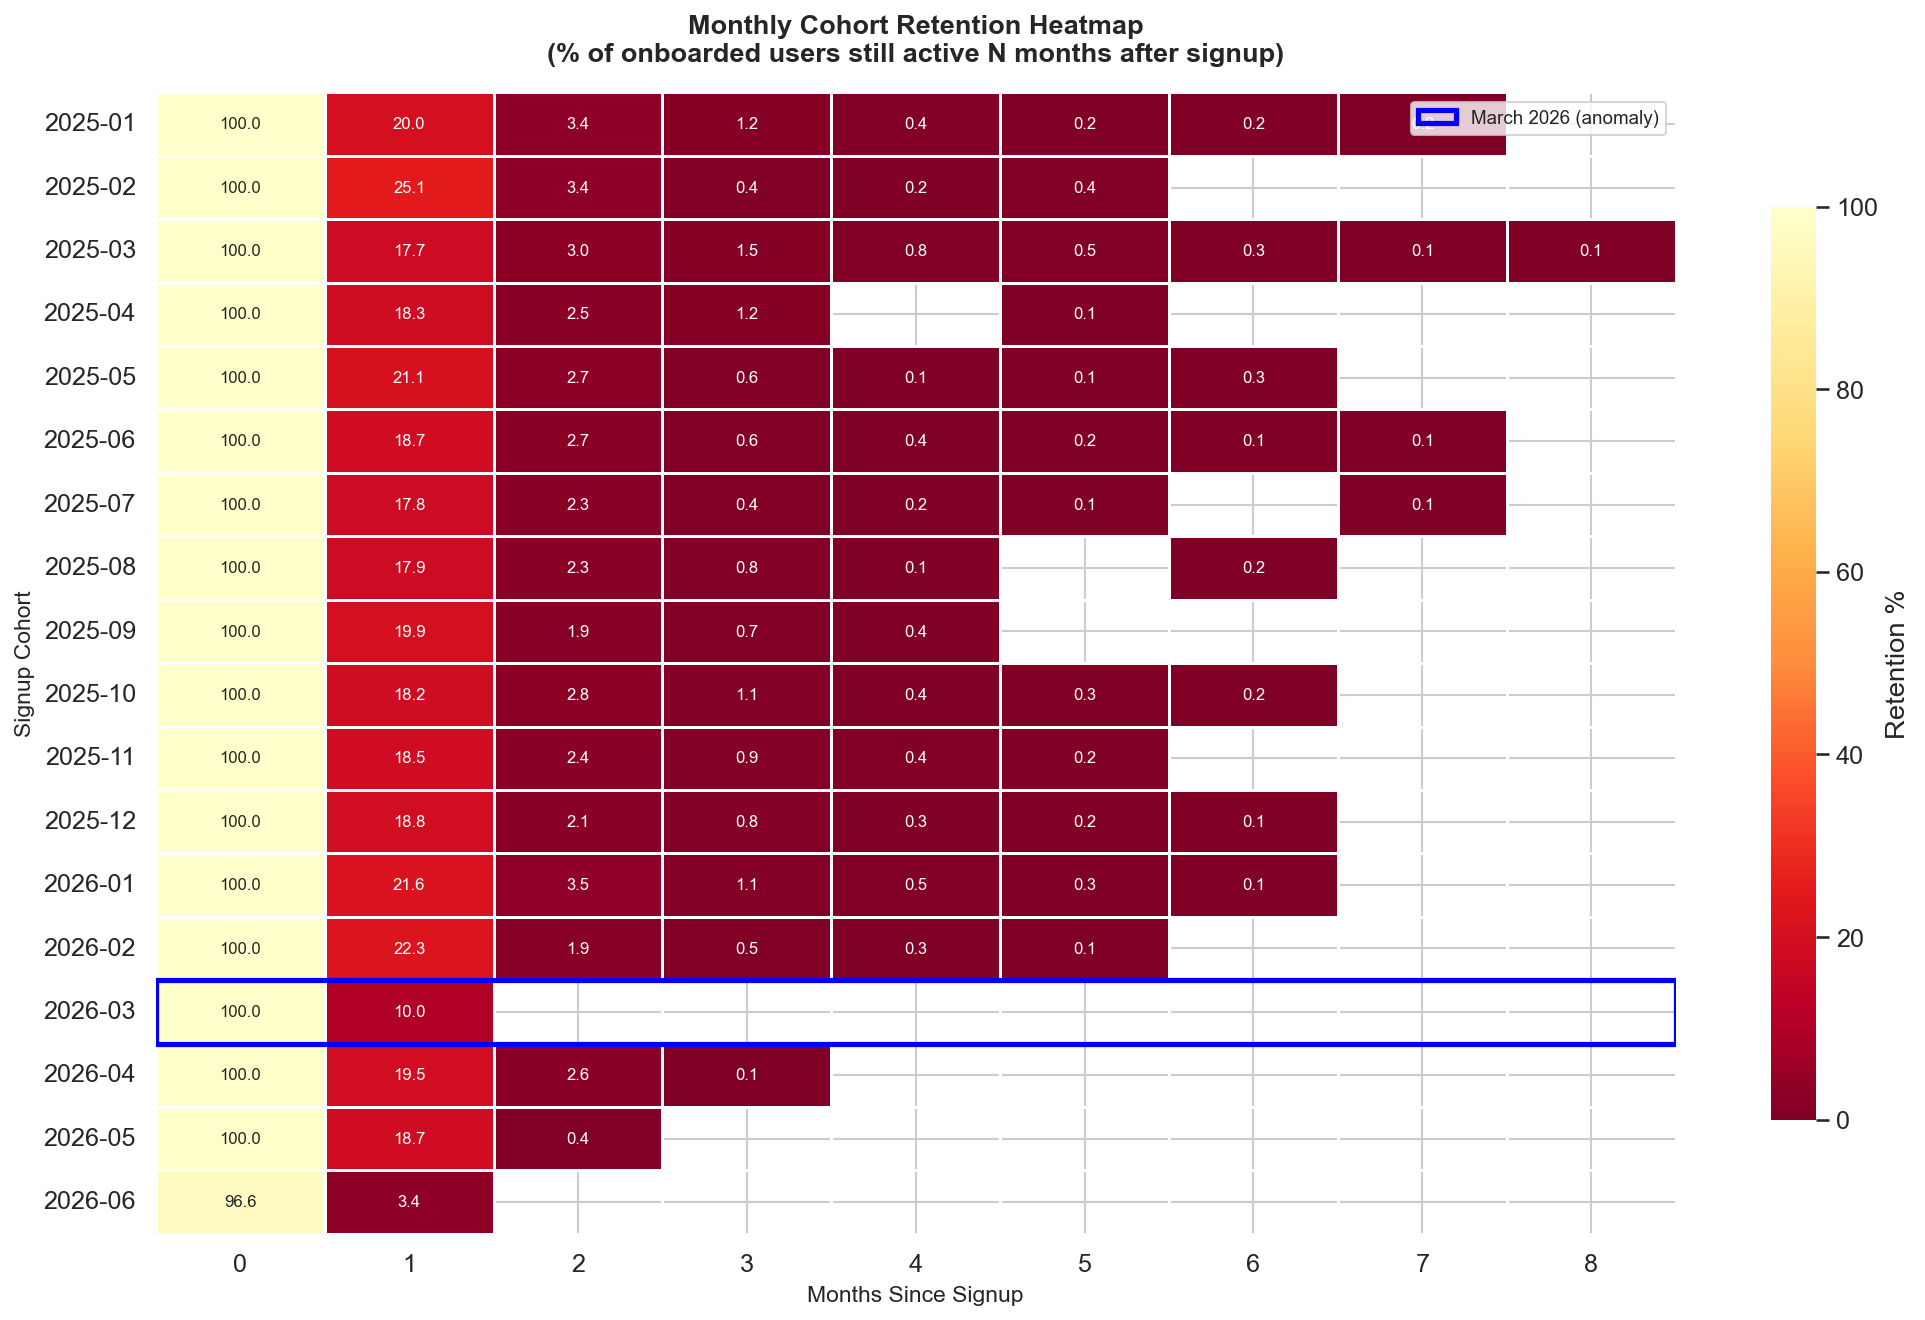

Saved: chart1_cohort_retention_heatmap.png


In [4]:
# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    retention_matrix,
    annot       = True,
    fmt         = ".1f",
    cmap        = "YlOrRd_r",
    linewidths  = 0.5,
    linecolor   = "white",
    vmin        = 0,
    vmax        = 100,
    ax          = ax,
    cbar_kws    = {"label": "Retention %", "shrink": 0.8},
    annot_kws   = {"size": 8}
)

ax.set_title(
    "Monthly Cohort Retention Heatmap\n(% of onboarded users still active N months after signup)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Months Since Signup", fontsize=11)
ax.set_ylabel("Signup Cohort", fontsize=11)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

# Highlight March 2026 row
march_idx = list(retention_matrix.index).index("2026-03") if "2026-03" in retention_matrix.index else None
if march_idx is not None:
    ax.add_patch(plt.Rectangle(
        (0, march_idx), len(cols_to_show), 1,
        fill=False, edgecolor="blue", lw=2.5, label="March 2026 (anomaly)"
    ))
    ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart1_cohort_retention_heatmap.png")
plt.show()
print("Saved: chart1_cohort_retention_heatmap.png")

## Chart 2: Retention Curves by Signup Channel
Line chart showing how Month 0, 1, 2, 3 retention differs
across Organic, Paid Ads, and Referral acquisition channels.
Answers: which channel brings the highest quality users?

In [5]:
# ── Build per-channel retention ──────────────────────────────────────────
onboarded_channel = users[users["onboarding_completed"] == True][
    ["user_id", "signup_cohort", "signup_channel"]
].copy()

logs_channel = logs.merge(onboarded_channel, on="user_id", how="inner")
logs_channel["activity_month"] = pd.to_datetime(
    logs_channel["event_timestamp"]
).dt.to_period("M").astype(str)

logs_channel["month_number"] = logs_channel.apply(
    lambda r: months_between(r["signup_cohort"], r["activity_month"]), axis=1
)
logs_channel = logs_channel[
    (logs_channel["month_number"] >= 0) &
    (logs_channel["month_number"] <= 6)
]

channel_sizes = onboarded_channel.groupby(
    ["signup_cohort", "signup_channel"]
)["user_id"].nunique().reset_index(name="cohort_size")

channel_activity = (
    logs_channel
    .groupby(["signup_cohort", "signup_channel", "month_number"])["user_id"]
    .nunique()
    .reset_index(name="active_users")
)

channel_activity = channel_activity.merge(
    channel_sizes, on=["signup_cohort", "signup_channel"]
)
channel_activity["retention_pct"] = (
    channel_activity["active_users"] / channel_activity["cohort_size"] * 100
).round(2)

channel_avg = (
    channel_activity
    .groupby(["signup_channel", "month_number"])["retention_pct"]
    .mean()
    .reset_index()
)

print(channel_avg.head(12))

   signup_channel  month_number  retention_pct
0         Organic             0      99.833333
1         Organic             1      17.451111
2         Organic             2       2.417500
3         Organic             3       0.759231
4         Organic             4       0.352222
5         Organic             5       0.272857
6         Organic             6       0.260000
7        Paid Ads             0      99.816111
8        Paid Ads             1      19.212778
9        Paid Ads             2       2.638750
10       Paid Ads             3       0.923571
11       Paid Ads             4       0.507273


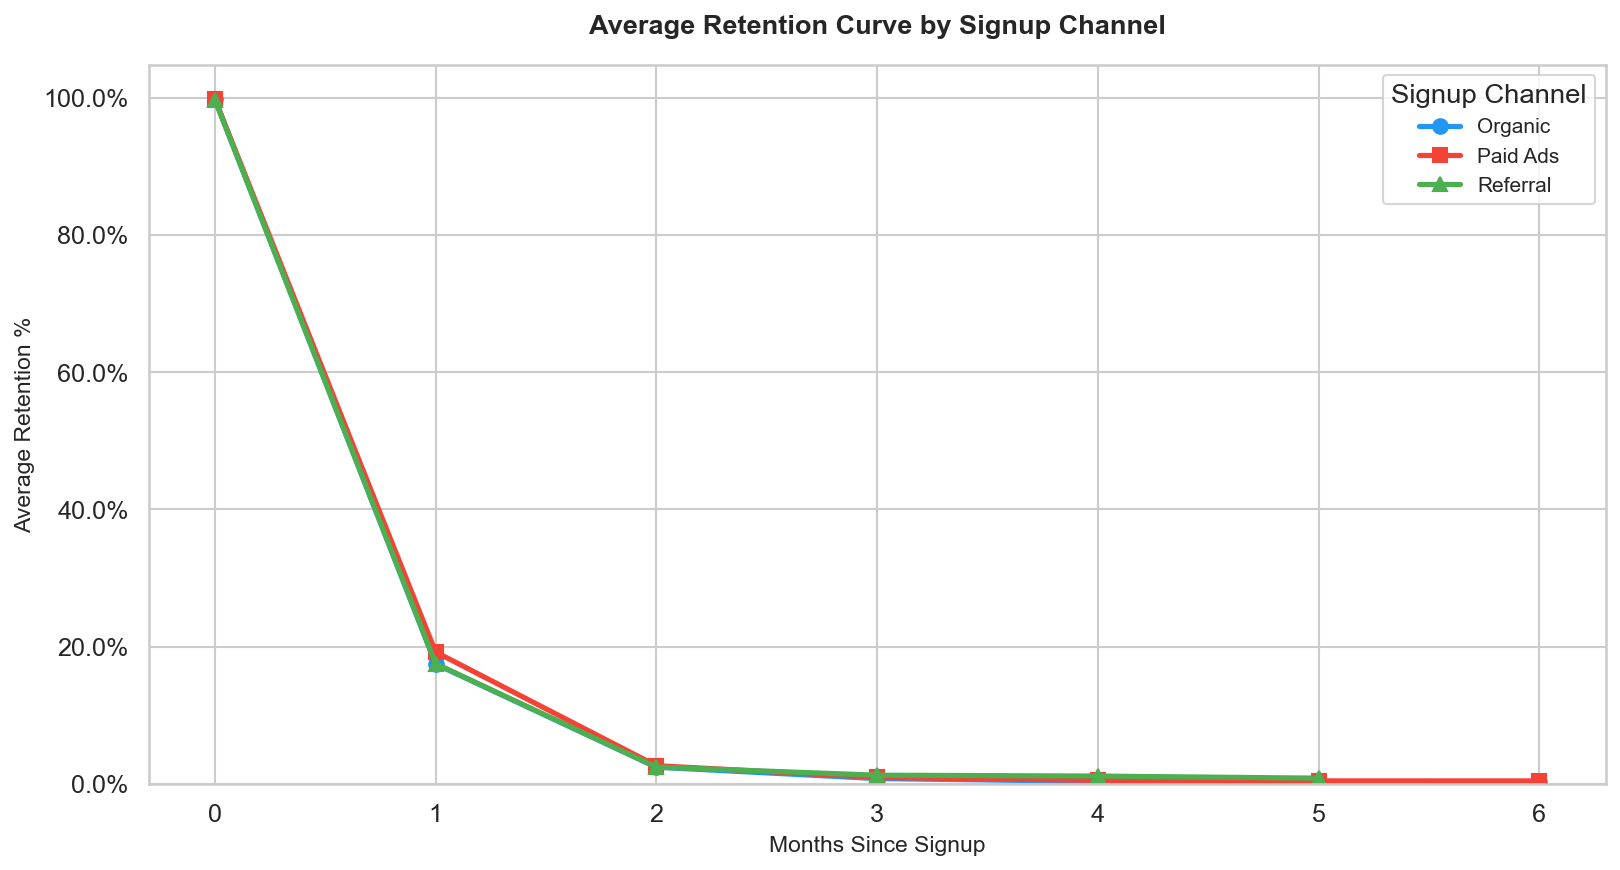

Saved: chart2_retention_by_channel.png


In [6]:
# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

channel_colors = {
    "Organic":  "#2196F3",
    "Paid Ads": "#F44336",
    "Referral": "#4CAF50",
}
channel_markers = {
    "Organic":  "o",
    "Paid Ads": "s",
    "Referral": "^",
}

for channel, grp in channel_avg.groupby("signup_channel"):
    ax.plot(
        grp["month_number"],
        grp["retention_pct"],
        marker    = channel_markers.get(channel, "o"),
        linewidth = 2.5,
        markersize = 7,
        color     = channel_colors.get(channel, "gray"),
        label     = channel
    )

ax.set_title(
    "Average Retention Curve by Signup Channel",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Months Since Signup", fontsize=11)
ax.set_ylabel("Average Retention %", fontsize=11)
ax.set_xticks(range(7))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(title="Signup Channel", fontsize=10)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart2_retention_by_channel.png")
plt.show()
print("Saved: chart2_retention_by_channel.png")

## Chart 3: Onboarding Funnel Drop-off
Horizontal bar chart showing how many unique users
reached each stage of the onboarding funnel.
Pinpoints exactly where users are abandoning the setup flow.

In [7]:
# ── Build funnel counts ──────────────────────────────────────────────────
funnel_steps = [
    "App_Open",
    "Onboarding_Step_1",
    "Onboarding_Completed",
    "Link_Bank_Account",
    "Initiate_Transfer",
]

funnel_counts = {}
for step in funnel_steps:
    funnel_counts[step] = logs[logs["event_name"] == step]["user_id"].nunique()

funnel_df = pd.DataFrame(
    list(funnel_counts.items()),
    columns=["step", "unique_users"]
)
funnel_df["conversion_from_top"] = (
    funnel_df["unique_users"] / funnel_df["unique_users"].iloc[0] * 100
).round(1)

print(funnel_df)

                   step  unique_users  conversion_from_top
0              App_Open         24927                100.0
1     Onboarding_Step_1         24927                100.0
2  Onboarding_Completed         18902                 75.8
3     Link_Bank_Account         10480                 42.0
4     Initiate_Transfer          7581                 30.4


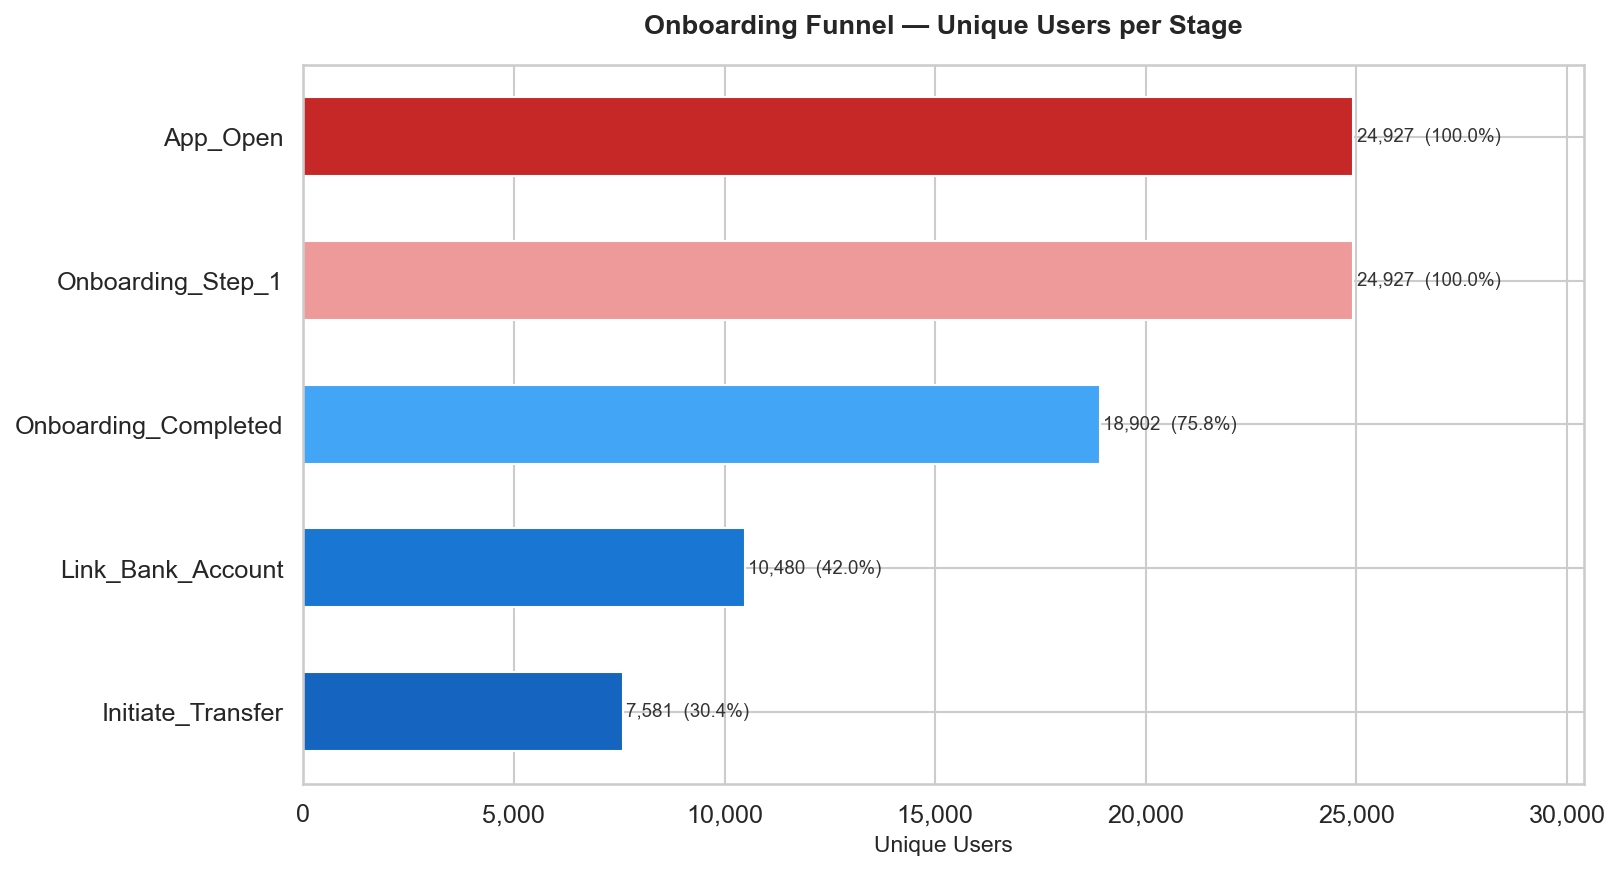

Saved: chart3_onboarding_funnel.png


In [8]:
# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = ["#1565C0", "#1976D2", "#42A5F5", "#EF9A9A", "#C62828"]

bars = ax.barh(
    funnel_df["step"][::-1],
    funnel_df["unique_users"][::-1],
    color  = bar_colors,
    height = 0.55,
    edgecolor = "white"
)

# Annotate with user count and conversion %
for i, (bar, row) in enumerate(zip(bars, funnel_df[::-1].itertuples())):
    ax.text(
        bar.get_width() + 80,
        bar.get_y() + bar.get_height() / 2,
        f"{row.unique_users:,}  ({row.conversion_from_top}%)",
        va="center", fontsize=9, color="#333333"
    )

ax.set_title(
    "Onboarding Funnel — Unique Users per Stage",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Unique Users", fontsize=11)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(right=funnel_df["unique_users"].max() * 1.22)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart3_onboarding_funnel.png")
plt.show()
print("Saved: chart3_onboarding_funnel.png")

## Chart 4: Feb 2026 vs March 2026 Friction Events
Side-by-side bar chart comparing KYC_Failed and
Support_Ticket_Opened event rates per 100 users
between the control cohort (Feb) and the broken cohort (March).
Broken down by device_os to isolate platform-specific issues.

In [9]:
# ── Build friction comparison ─────────────────────────────────────────────
target_cohorts = ["2026-02", "2026-03"]
cohort_users   = users[users["signup_cohort"].isin(target_cohorts)][
    ["user_id", "signup_cohort", "device_os"]
].copy()

cohort_logs = logs.merge(cohort_users, on="user_id", how="inner")
cohort_logs = cohort_logs[
    cohort_logs["event_name"].isin(["KYC_Failed", "Support_Ticket_Opened"])
]

friction_counts = (
    cohort_logs
    .groupby(["signup_cohort", "device_os", "event_name"])["event_id"]
    .count()
    .reset_index(name="event_count")
)

cohort_device_pop = (
    cohort_users
    .groupby(["signup_cohort", "device_os"])["user_id"]
    .nunique()
    .reset_index(name="users_in_segment")
)

friction_counts = friction_counts.merge(
    cohort_device_pop, on=["signup_cohort", "device_os"]
)
friction_counts["rate_per_100"] = (
    friction_counts["event_count"] / friction_counts["users_in_segment"] * 100
).round(2)

friction_counts = friction_counts[friction_counts["device_os"].isin(["iOS", "Android"])]
friction_counts["label"] = friction_counts["signup_cohort"] + " | " + friction_counts["device_os"]

print(friction_counts)

  signup_cohort device_os             event_name  event_count  \
0       2026-02   Android             KYC_Failed           32   
1       2026-02   Android  Support_Ticket_Opened           28   
3       2026-02       iOS             KYC_Failed           41   
4       2026-02       iOS  Support_Ticket_Opened           36   
5       2026-03   Android             KYC_Failed           37   
6       2026-03   Android  Support_Ticket_Opened           21   
8       2026-03       iOS             KYC_Failed           39   
9       2026-03       iOS  Support_Ticket_Opened           34   

   users_in_segment  rate_per_100              label  
0               715          4.48  2026-02 | Android  
1               715          3.92  2026-02 | Android  
3               858          4.78      2026-02 | iOS  
4               858          4.20      2026-02 | iOS  
5               811          4.56  2026-03 | Android  
6               811          2.59  2026-03 | Android  
8              1010          

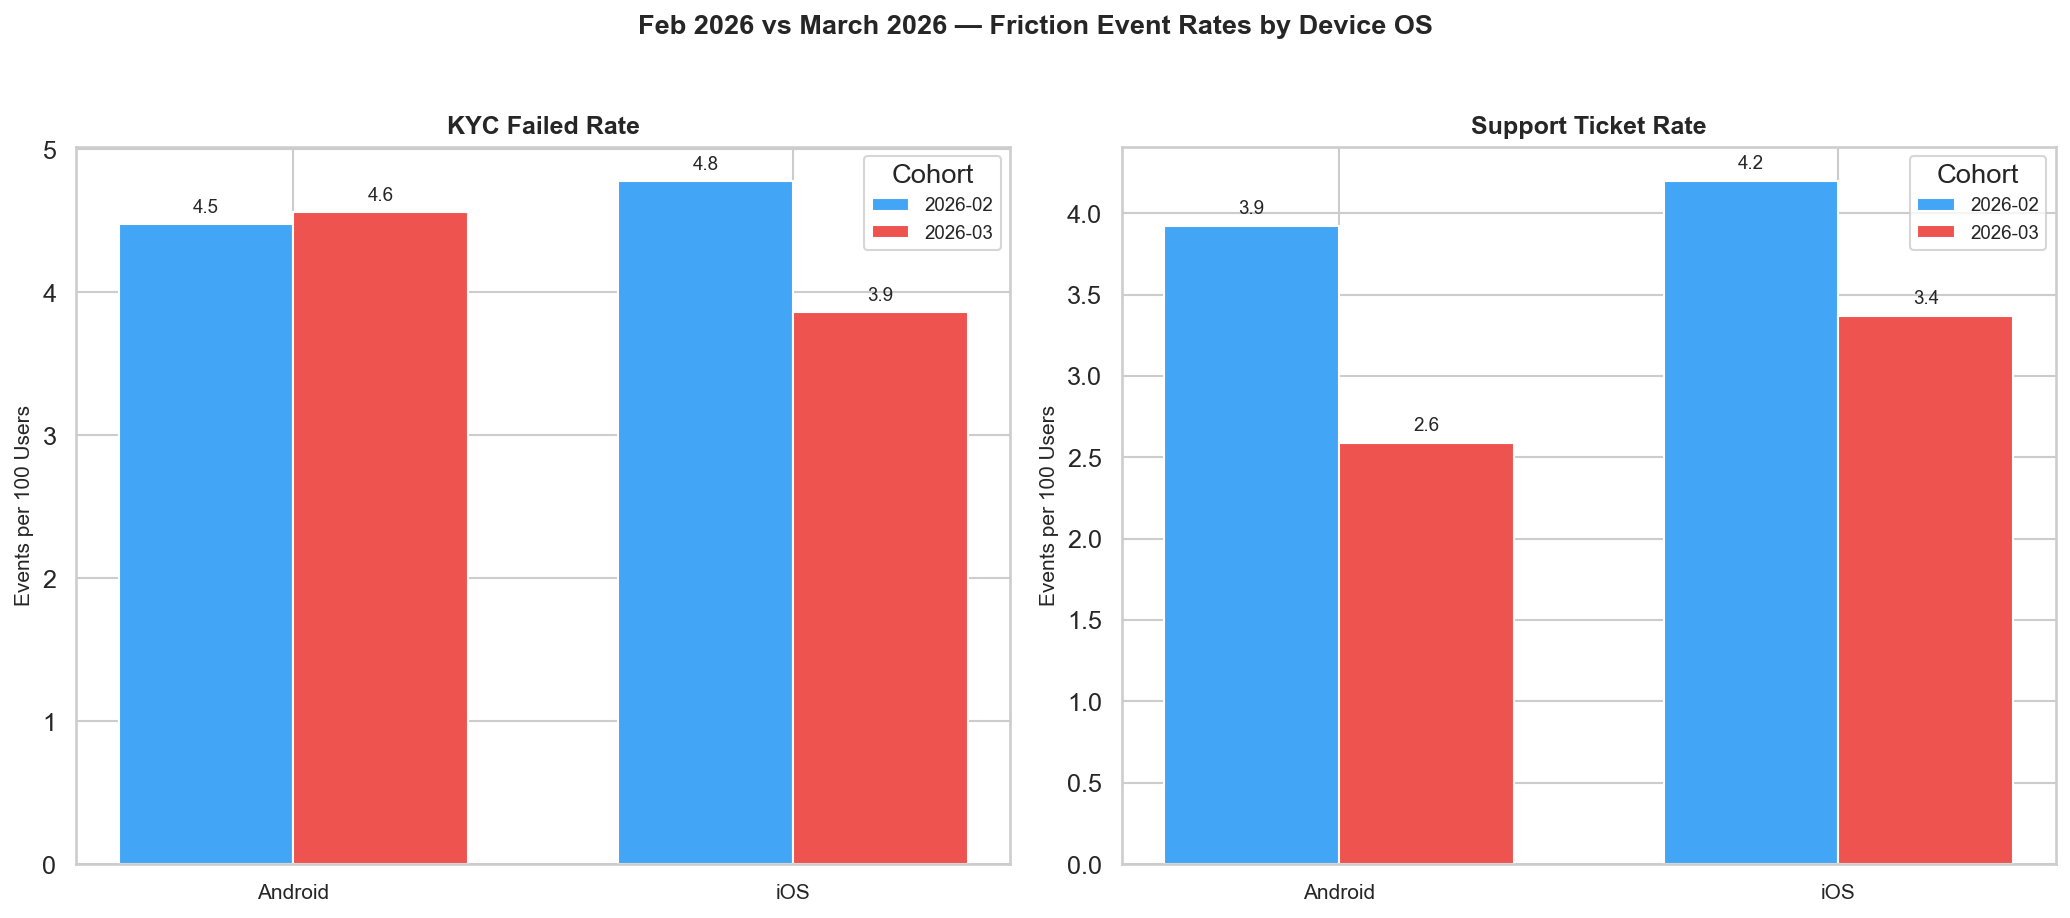

Saved: chart4_march_friction_analysis.png


In [10]:
# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

friction_events = ["KYC_Failed", "Support_Ticket_Opened"]
event_colors    = {"2026-02": "#42A5F5", "2026-03": "#EF5350"}
titles          = ["KYC Failed Rate", "Support Ticket Rate"]

for ax, event, title in zip(axes, friction_events, titles):
    subset = friction_counts[friction_counts["event_name"] == event].copy()
    subset = subset.sort_values(["device_os", "signup_cohort"])

    x      = np.arange(subset["device_os"].nunique())
    width  = 0.35
    devices = sorted(subset["device_os"].unique())

    for i, cohort in enumerate(["2026-02", "2026-03"]):
        vals = [
            subset[
                (subset["device_os"] == d) &
                (subset["signup_cohort"] == cohort)
            ]["rate_per_100"].values
            for d in devices
        ]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        bars = ax.bar(
            x + i * width,
            vals,
            width,
            label     = cohort,
            color     = event_colors[cohort],
            edgecolor = "white"
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=9
            )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Events per 100 Users", fontsize=10)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(devices, fontsize=10)
    ax.legend(title="Cohort", fontsize=9)
    ax.set_ylim(bottom=0)

fig.suptitle(
    "Feb 2026 vs March 2026 — Friction Event Rates by Device OS",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart4_march_friction_analysis.png")
plt.show()
print("Saved: chart4_march_friction_analysis.png")

## Chart 5: Churn vs Active User — Transaction Value Comparison
Bar chart comparing average total spend and average transaction
count between users who stayed active past Month 0 vs those
who churned immediately. Puts a dollar figure on the cost of churn.

In [11]:
# ── Build churn segments ─────────────────────────────────────────────────
onboarded_users = users[users["onboarding_completed"] == True][
    ["user_id", "signup_timestamp"]
].copy()

onboarded_users["cutoff"] = onboarded_users["signup_timestamp"] + pd.Timedelta(days=30)

# Users with any activity after Month 0
post_m0_logs = logs.merge(
    onboarded_users[["user_id", "cutoff"]], on="user_id", how="inner"
)
post_m0_logs = post_m0_logs[post_m0_logs["event_timestamp"] >= post_m0_logs["cutoff"]]

post_m0_txns = txns.merge(
    onboarded_users[["user_id", "cutoff"]], on="user_id", how="inner"
)
post_m0_txns = post_m0_txns[
    post_m0_txns["transaction_timestamp"] >= post_m0_txns["cutoff"]
]

active_after_m0 = set(post_m0_logs["user_id"]).union(set(post_m0_txns["user_id"]))

onboarded_users["segment"] = onboarded_users["user_id"].apply(
    lambda uid: "Active / Healthy" if uid in active_after_m0 else "Early Churned"
)

# Transaction summary per user
txn_summary = (
    txns[txns["status"] == "Success"]
    .groupby("user_id")
    .agg(
        total_spend = ("amount", "sum"),
        txn_count   = ("transaction_id", "count")
    )
    .reset_index()
)

segment_txns = onboarded_users.merge(txn_summary, on="user_id", how="left")
segment_txns["total_spend"] = segment_txns["total_spend"].fillna(0)
segment_txns["txn_count"]   = segment_txns["txn_count"].fillna(0)

summary = segment_txns.groupby("segment").agg(
    user_count    = ("user_id", "count"),
    avg_spend     = ("total_spend", "mean"),
    avg_txn_count = ("txn_count", "mean")
).round(2)

print(summary)

                  user_count  avg_spend  avg_txn_count
segment                                               
Active / Healthy        1095     705.53           4.09
Early Churned          17862     329.00           1.92


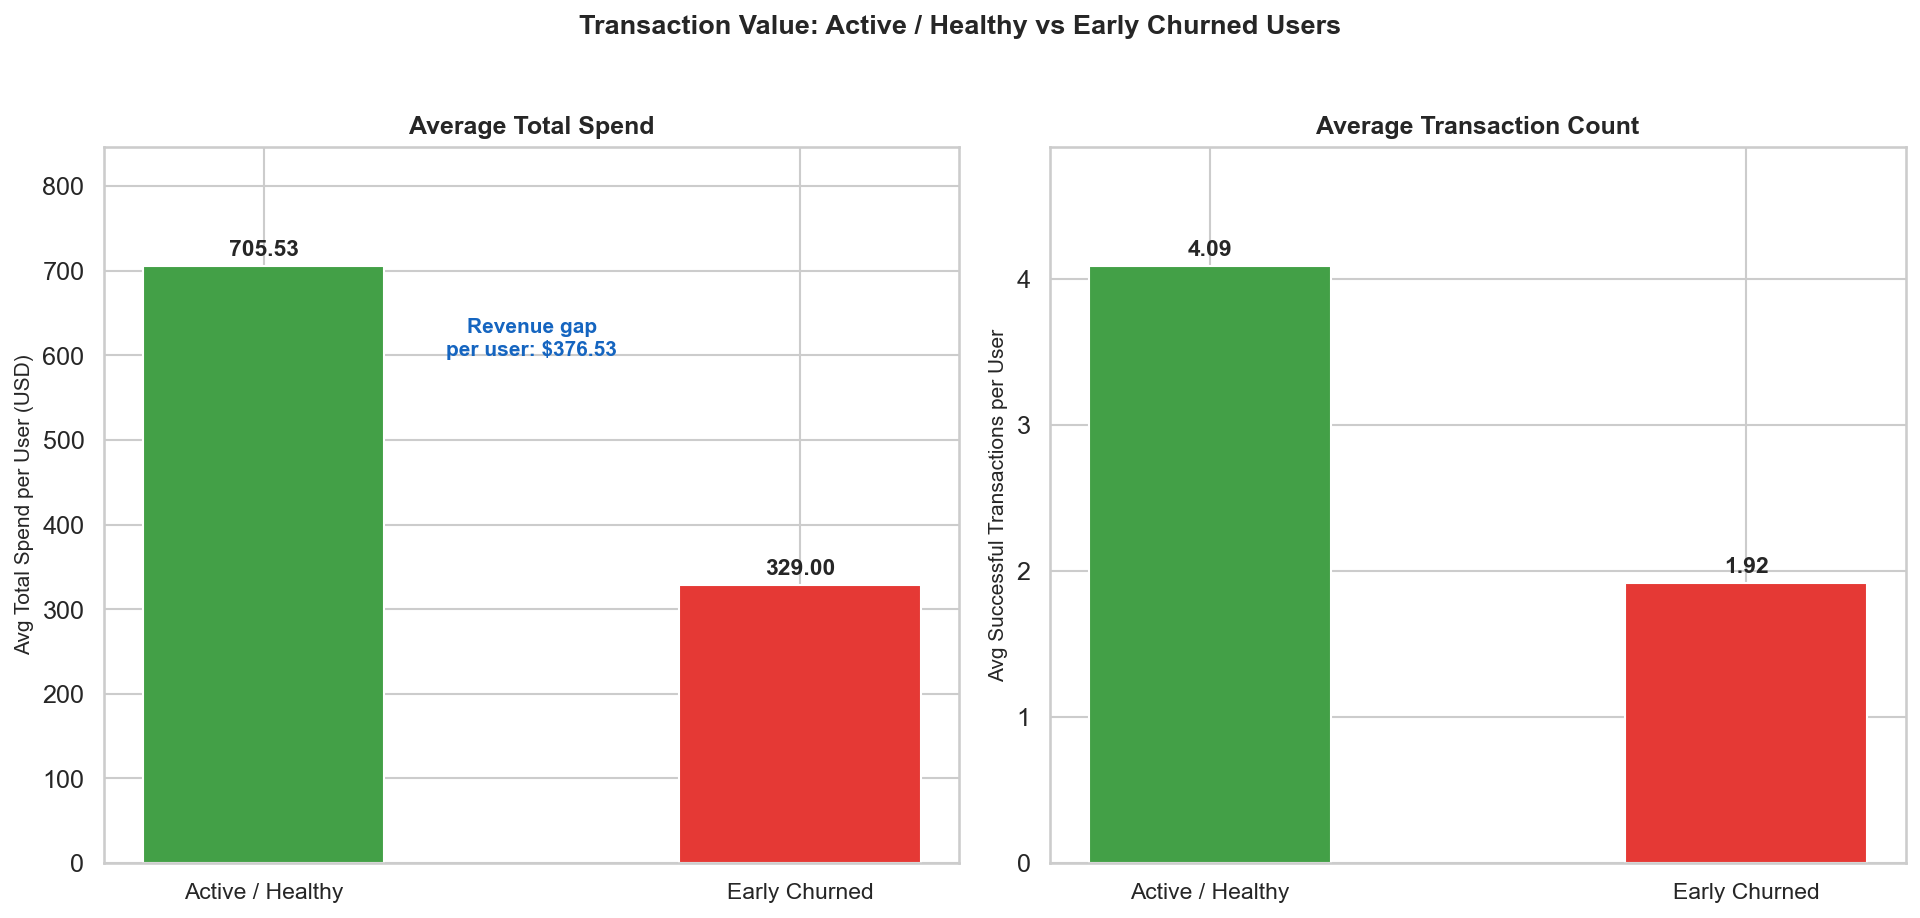

Saved: chart5_churn_value_comparison.png


In [12]:
# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

segment_order  = ["Active / Healthy", "Early Churned"]
segment_colors = ["#43A047", "#E53935"]
metrics        = ["avg_spend", "avg_txn_count"]
ylabels        = ["Avg Total Spend per User (USD)", "Avg Successful Transactions per User"]
titles         = ["Average Total Spend", "Average Transaction Count"]

for ax, metric, ylabel, title in zip(axes, metrics, ylabels, titles):
    vals = [summary.loc[s, metric] if s in summary.index else 0 for s in segment_order]
    bars = ax.bar(
        segment_order,
        vals,
        color     = segment_colors,
        width     = 0.45,
        edgecolor = "white"
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            f"{val:,.2f}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(bottom=0, top=max(vals) * 1.2)
    ax.tick_params(axis="x", labelsize=11)

# Annotate the revenue gap
gap = summary.loc["Active / Healthy", "avg_spend"] - summary.loc["Early Churned", "avg_spend"]
axes[0].annotate(
    f"Revenue gap\nper user: ${gap:,.2f}",
    xy        = (0.5, max(
        summary.loc["Active / Healthy", "avg_spend"],
        summary.loc["Early Churned",    "avg_spend"]
    ) * 0.85),
    ha        = "center",
    fontsize  = 10,
    color     = "#1565C0",
    fontweight= "bold"
)

fig.suptitle(
    "Transaction Value: Active / Healthy vs Early Churned Users",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart5_churn_value_comparison.png")
plt.show()
print("Saved: chart5_churn_value_comparison.png")

## All Charts Exported

In [13]:
charts = [
    "chart1_cohort_retention_heatmap.png",
    "chart2_retention_by_channel.png",
    "chart3_onboarding_funnel.png",
    "chart4_march_friction_analysis.png",
    "chart5_churn_value_comparison.png",
]

print("Visuals saved to ../visuals/")
print("-" * 45)
for c in charts:
    path   = f"{OUTPUT_DIR}/{c}"
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING':6} {c}")

print("\nPhase 4 complete.")

Visuals saved to ../visuals/
---------------------------------------------
  OK     chart1_cohort_retention_heatmap.png
  OK     chart2_retention_by_channel.png
  OK     chart3_onboarding_funnel.png
  OK     chart4_march_friction_analysis.png
  OK     chart5_churn_value_comparison.png

Phase 4 complete.
